# Verifica risultati simulazione - Bologna morning

Notebook per ispezionare gli snapshot GeoJSON prodotti in `../results/bologna_morning`.

Controlla struttura dei file, feature vuote, metriche aggregate nel tempo, edge piu congestionati e una vista rapida della rete colorata per congestione.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path('/home/fede/code/nomad/results/bologna_morning')
FILES = sorted(RESULT_DIR.glob('network_state_*.geojson'))

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)
plt.rcParams['figure.figsize'] = (12, 6)

print(f'Cartella risultati: {RESULT_DIR}')
print(f'File trovati: {len(FILES)}')
for path in FILES:
    print(f'- {path.name} ({path.stat().st_size:,} bytes)')

Cartella risultati: /home/fede/code/nomad/results/bologna_morning
File trovati: 8
- network_state_025200.geojson (42 bytes)
- network_state_026100.geojson (40,461 bytes)
- network_state_027000.geojson (51,427 bytes)
- network_state_027900.geojson (53,863 bytes)
- network_state_028800.geojson (63,124 bytes)
- network_state_029700.geojson (55,333 bytes)
- network_state_030600.geojson (52,158 bytes)
- network_state_031500.geojson (48,031 bytes)


## Caricamento e controlli base

In [2]:
def seconds_from_name(path: Path) -> int:
    match = re.search(r'network_state_(\d+)\.geojson$', path.name)
    if not match:
        raise ValueError(f'Nome file inatteso: {path.name}')
    return int(match.group(1))


def hhmmss(seconds: int) -> str:
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f'{h:02d}:{m:02d}:{s:02d}'


def load_geojson(path: Path) -> dict:
    with path.open() as f:
        data = json.load(f)
    if data.get('type') != 'FeatureCollection':
        raise ValueError(f'{path.name}: type={data.get("type")!r}, atteso FeatureCollection')
    if not isinstance(data.get('features'), list):
        raise ValueError(f'{path.name}: campo features mancante o non lista')
    return data


snapshots = []
errors = []
for path in FILES:
    try:
        data = load_geojson(path)
        seconds = seconds_from_name(path)
        snapshots.append({
            'path': path,
            'seconds': seconds,
            'time': hhmmss(seconds),
            'features': data['features'],
            'feature_count': len(data['features']),
            'size_bytes': path.stat().st_size,
        })
    except Exception as exc:
        errors.append({'file': path.name, 'error': str(exc)})

summary = pd.DataFrame([
    {
        'file': s['path'].name,
        'time': s['time'],
        'seconds': s['seconds'],
        'feature_count': s['feature_count'],
        'size_kb': s['size_bytes'] / 1024,
    }
    for s in snapshots
])

print('Errori di caricamento:', len(errors))
if errors:
    display(pd.DataFrame(errors))
display(summary)

Errori di caricamento: 0


,file,time,seconds,feature_count,size_kb
0,network_state_025200.geojson,07:00:00,25200,0,0.041016
1,network_state_026100.geojson,07:15:00,26100,166,39.512695
2,network_state_027000.geojson,07:30:00,27000,211,50.221680
3,network_state_027900.geojson,07:45:00,27900,221,52.600586
4,network_state_028800.geojson,08:00:00,28800,259,61.644531
5,network_state_029700.geojson,08:15:00,29700,227,54.036133
6,network_state_030600.geojson,08:30:00,30600,214,50.935547
7,network_state_031500.geojson,08:45:00,31500,197,46.905273


In [3]:
empty = summary.loc[summary['feature_count'] == 0, ['file', 'time', 'feature_count']]
print(f'Snapshot vuoti: {len(empty)}')
display(empty)

non_empty_features = [feature for s in snapshots for feature in s['features']]
if non_empty_features:
    geometry_types = pd.Series([feature.get('geometry', {}).get('type') for feature in non_empty_features]).value_counts()
    property_keys = sorted({key for feature in non_empty_features for key in feature.get('properties', {}).keys()})
    print('Tipi geometria:')
    display(geometry_types.to_frame('count'))
    print('Chiavi properties:', property_keys)
    print('Esempio feature:')
    display(non_empty_features[0])
else:
    print('Nessuna feature trovata nei risultati.')

Snapshot vuoti: 1


,file,time,feature_count
0,network_state_025200.geojson,07:00:00,0


Tipi geometria:


,count
LineString,1495


Chiavi properties: ['congestion', 'count', 'edge_id', 'free_flow_time_s', 'road_class', 'travel_time_s']
Esempio feature:


{'type': 'Feature',
 'geometry': {'type': 'LineString',
  'coordinates': [[11.280274, 44.456406], [11.280045, 44.456673]]},
 'properties': {'edge_id': 1,
  'road_class': 0,
  'congestion': 0.0,
  'travel_time_s': 0.965025,
  'count': 1,
  'free_flow_time_s': 0.965025}}

## Metriche aggregate

In [4]:
rows = []
for s in snapshots:
    for feature in s['features']:
        props = feature.get('properties', {}) or {}
        rows.append({
            'file': s['path'].name,
            'time': s['time'],
            'seconds': s['seconds'],
            'edge_id': props.get('edge_id'),
            'road_class': props.get('road_class'),
            'congestion': props.get('congestion'),
            'count': props.get('count'),
            'travel_time_s': props.get('travel_time_s'),
            'free_flow_time_s': props.get('free_flow_time_s'),
        })

df = pd.DataFrame(rows)
numeric_cols = ['edge_id', 'road_class', 'congestion', 'count', 'travel_time_s', 'free_flow_time_s']
for col in numeric_cols:
    if col in df:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if df.empty:
    print('DataFrame vuoto: non ci sono feature da aggregare.')
else:
    df['delay_s'] = df['travel_time_s'] - df['free_flow_time_s']
    df['speed_ratio'] = df['travel_time_s'] / df['free_flow_time_s']
    display(df.head())
    display(df.describe(include='all'))

,file,time,seconds,edge_id,road_class,congestion,count,travel_time_s,free_flow_time_s,delay_s,speed_ratio
0,network_state_026100.geojson,07:15:00,26100,1,0,0.0,1,0.965025,0.965025,0.000000,1.000000
1,network_state_026100.geojson,07:15:00,26100,558,1,1.0,1,0.624753,0.543264,0.081489,1.149999
2,network_state_026100.geojson,07:15:00,26100,3337,4,0.0,1,8.659204,8.659204,0.000000,1.000000
3,network_state_026100.geojson,07:15:00,26100,4099,4,0.0,1,0.705186,0.705186,0.000000,1.000000
4,network_state_026100.geojson,07:15:00,26100,4621,10,0.0,1,1.276976,1.276976,0.000000,1.000000


,file,time,seconds,edge_id,road_class,congestion,count,travel_time_s,free_flow_time_s,delay_s,speed_ratio
count,1495,1495,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000
unique,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,network_state_028800.geojson,08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,259,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,28863.210702,121928.333779,5.016054,0.248294,1.005351,2.142249,2.126505,0.015745,1.037244
std,NaN,NaN,1712.263153,105731.058599,3.706394,0.416602,0.072980,3.713292,3.719306,0.034416,0.062490
min,NaN,NaN,26100.000000,0.000000,0.000000,0.000000,1.000000,0.012523,0.010889,0.000000,1.000000
25%,NaN,NaN,27000.000000,30855.000000,2.000000,0.000000,1.000000,0.507798,0.483246,0.000000,1.000000
50%,NaN,NaN,28800.000000,88795.000000,4.000000,0.000000,1.000000,0.927548,0.907312,0.000000,1.000000
75%,NaN,NaN,30600.000000,192249.000000,8.000000,0.510328,1.000000,2.128875,2.128875,0.021319,1.076550


,seconds,time,edges,active_edges,total_count,mean_count,mean_congestion,p95_congestion,max_congestion,mean_travel_time_s,mean_delay_s,max_delay_s
0,26100,07:15:00,166,166,167,1.006024,0.275127,1.0,1.0,2.240603,0.016691,0.135947
1,27000,07:30:00,211,211,213,1.009479,0.202378,1.0,1.0,1.933659,0.012153,0.142804
2,27900,07:45:00,221,221,224,1.013575,0.254785,1.0,1.0,2.404569,0.014739,0.132119
3,28800,08:00:00,259,259,260,1.003861,0.249403,1.0,1.0,2.231810,0.018240,0.687366
4,29700,08:15:00,227,227,227,1.000000,0.261788,1.0,1.0,1.921682,0.016596,0.198336
5,30600,08:30:00,214,214,215,1.004673,0.246489,1.0,1.0,2.137557,0.015937,0.197378
6,31500,08:45:00,197,197,197,1.000000,0.252531,1.0,1.0,2.130014,0.015451,0.159045


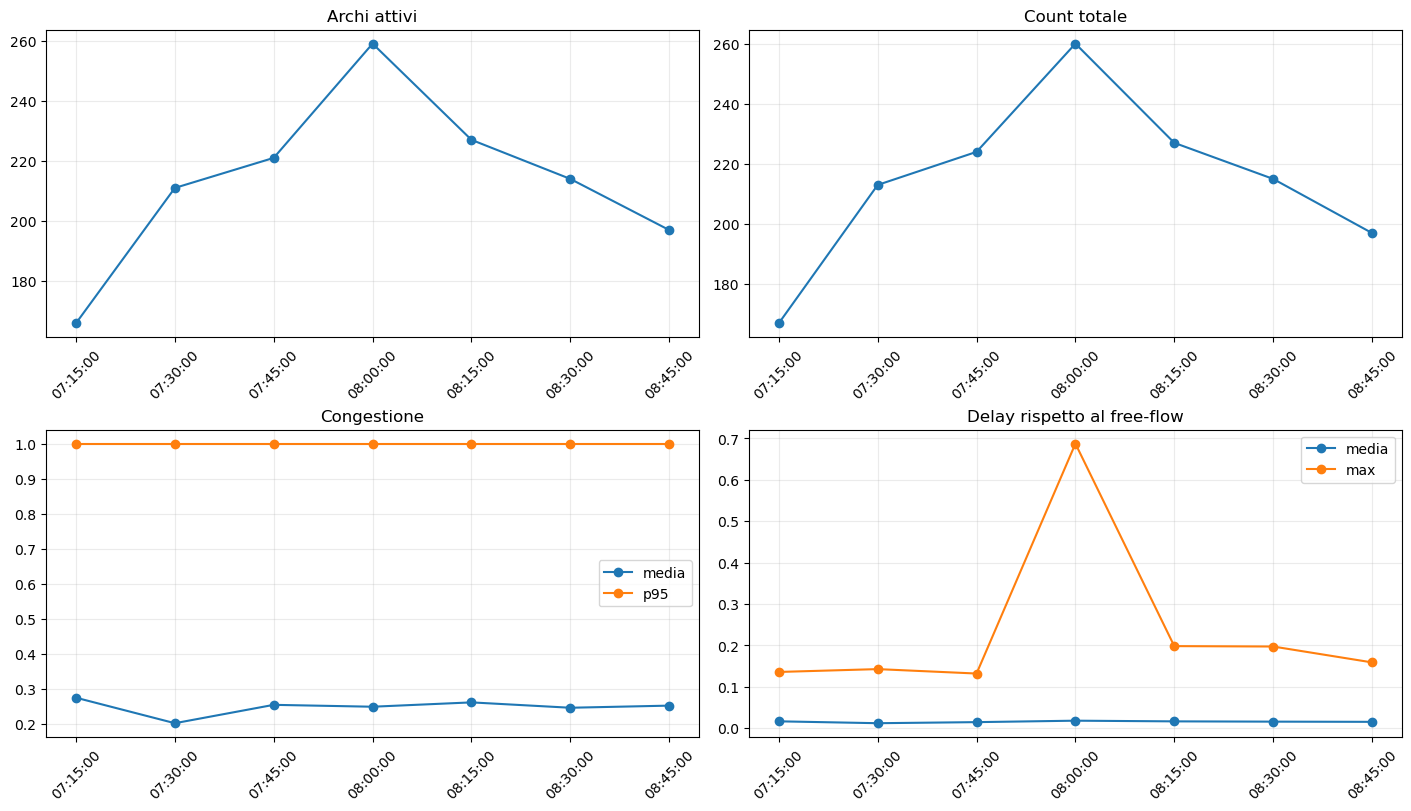

In [5]:
if not df.empty:
    agg = df.groupby(['seconds', 'time'], as_index=False).agg(
        edges=('edge_id', 'count'),
        active_edges=('edge_id', 'nunique'),
        total_count=('count', 'sum'),
        mean_count=('count', 'mean'),
        mean_congestion=('congestion', 'mean'),
        p95_congestion=('congestion', lambda x: x.quantile(0.95)),
        max_congestion=('congestion', 'max'),
        mean_travel_time_s=('travel_time_s', 'mean'),
        mean_delay_s=('delay_s', 'mean'),
        max_delay_s=('delay_s', 'max'),
    ).sort_values('seconds')
    display(agg)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    axes = axes.ravel()
    axes[0].plot(agg['time'], agg['active_edges'], marker='o')
    axes[0].set_title('Archi attivi')
    axes[1].plot(agg['time'], agg['total_count'], marker='o')
    axes[1].set_title('Count totale')
    axes[2].plot(agg['time'], agg['mean_congestion'], marker='o', label='media')
    axes[2].plot(agg['time'], agg['p95_congestion'], marker='o', label='p95')
    axes[2].set_title('Congestione')
    axes[2].legend()
    axes[3].plot(agg['time'], agg['mean_delay_s'], marker='o', label='media')
    axes[3].plot(agg['time'], agg['max_delay_s'], marker='o', label='max')
    axes[3].set_title('Delay rispetto al free-flow')
    axes[3].legend()
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis='x', rotation=45)
    plt.show()

## Edge critici

In [6]:
if not df.empty:
    critical = df.sort_values(['congestion', 'count', 'delay_s'], ascending=False).head(20)
    display(critical[['time', 'edge_id', 'road_class', 'congestion', 'count', 'travel_time_s', 'free_flow_time_s', 'delay_s']])

    by_edge = df.groupby('edge_id', as_index=False).agg(
        observations=('edge_id', 'count'),
        max_congestion=('congestion', 'max'),
        mean_congestion=('congestion', 'mean'),
        max_count=('count', 'max'),
        total_count=('count', 'sum'),
        max_delay_s=('delay_s', 'max'),
    ).sort_values(['max_congestion', 'total_count'], ascending=False)
    display(by_edge.head(20))

,time,edge_id,road_class,congestion,count,travel_time_s,free_flow_time_s,delay_s
456,07:45:00,52234,6,1.0,2,0.617838,0.537250,0.080588
782,08:00:00,182480,12,1.0,1,5.269807,4.582441,0.687366
1077,08:15:00,364741,12,1.0,1,1.520574,1.322238,0.198336
777,08:00:00,167244,12,1.0,1,1.301100,1.131392,0.169708
339,07:30:00,256206,14,1.0,1,1.094832,0.952028,0.142804
1071,08:15:00,331147,12,1.0,1,1.043282,0.907202,0.136080
1080,08:15:00,366737,8,1.0,1,1.013509,0.881312,0.132197
779,08:00:00,175928,8,1.0,1,1.009165,0.877535,0.131630
1107,08:30:00,10576,13,1.0,1,1.009018,0.877407,0.131611
1142,08:30:00,32403,8,1.0,1,0.969893,0.843385,0.126508


,edge_id,observations,max_congestion,mean_congestion,max_count,total_count,max_delay_s
215,12354,2,1.0,1.0,1,2,0.088095
508,52234,1,1.0,1.0,2,2,0.080588
647,73047,2,1.0,1.0,1,2,0.060356
976,170167,2,1.0,1.0,1,2,0.013767
1041,186216,2,1.0,1.0,1,2,0.050012
1088,194099,2,1.0,1.0,1,2,0.066876
1361,331496,2,1.0,1.0,1,2,0.017368
3,139,1,1.0,1.0,1,1,0.068112
4,558,1,1.0,1.0,1,1,0.081489
7,676,1,1.0,1.0,1,1,0.074042


## Mappa rapida della rete

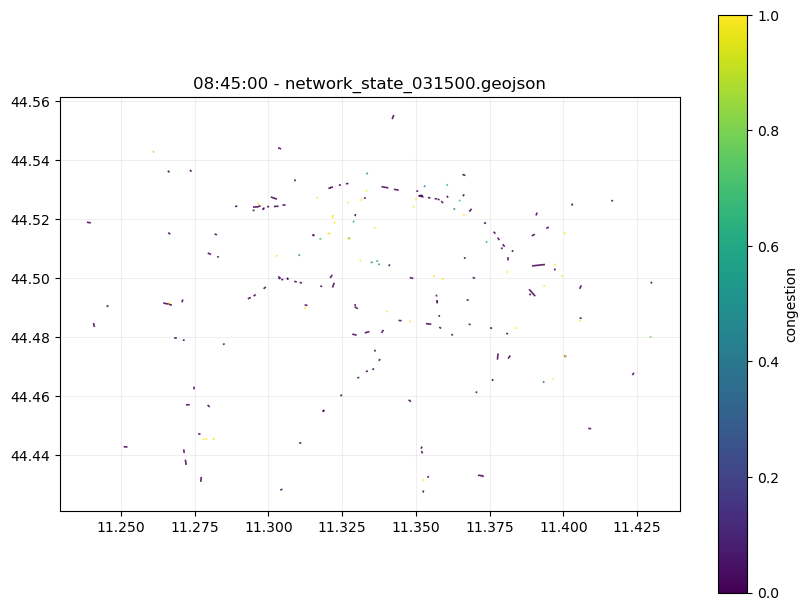

In [7]:
def iter_lines(geometry):
    if not geometry:
        return
    gtype = geometry.get('type')
    coords = geometry.get('coordinates')
    if gtype == 'LineString':
        yield coords
    elif gtype == 'MultiLineString':
        yield from coords


def plot_snapshot(snapshot_index=-1, color_by='congestion'):
    non_empty = [s for s in snapshots if s['feature_count'] > 0]
    if not non_empty:
        print('Nessuno snapshot non vuoto da plottare.')
        return
    s = non_empty[snapshot_index]
    values = []
    lines = []
    for feature in s['features']:
        props = feature.get('properties', {}) or {}
        value = props.get(color_by, np.nan)
        for line in iter_lines(feature.get('geometry')):
            if line:
                lines.append(line)
                values.append(value)

    values = pd.to_numeric(pd.Series(values), errors='coerce')
    cmap = plt.cm.viridis
    norm = plt.Normalize(values.min(), values.max()) if values.notna().any() else None

    fig, ax = plt.subplots(figsize=(10, 10))
    for line, value in zip(lines, values):
        xs = [point[0] for point in line]
        ys = [point[1] for point in line]
        color = cmap(norm(value)) if norm and pd.notna(value) else '0.5'
        ax.plot(xs, ys, color=color, linewidth=1.2, alpha=0.85)

    if norm:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        fig.colorbar(sm, ax=ax, shrink=0.75, label=color_by)
    ax.set_title(f'{s["time"]} - {s["path"].name}')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    plt.show()


plot_snapshot(-1, color_by='congestion')

## Controlli rapidi di plausibilita

In [8]:
checks = []
checks.append(('almeno un file', len(FILES) > 0))
checks.append(('tutti i file caricati senza errori', len(errors) == 0))
checks.append(('tempi ordinati e univoci', summary['seconds'].is_monotonic_increasing and summary['seconds'].is_unique if not summary.empty else False))
checks.append(('almeno uno snapshot con feature', bool((summary['feature_count'] > 0).any()) if not summary.empty else False))

if not df.empty:
    checks.extend([
        ('edge_id sempre presente', df['edge_id'].notna().all()),
        ('congestion numerica e non negativa', df['congestion'].notna().all() and (df['congestion'] >= 0).all()),
        ('count numerico e non negativo', df['count'].notna().all() and (df['count'] >= 0).all()),
        ('travel_time_s >= 0', df['travel_time_s'].notna().all() and (df['travel_time_s'] >= 0).all()),
        ('free_flow_time_s >= 0', df['free_flow_time_s'].notna().all() and (df['free_flow_time_s'] >= 0).all()),
    ])

check_df = pd.DataFrame(checks, columns=['check', 'ok'])
display(check_df)

failed = check_df.loc[~check_df['ok']]
if failed.empty:
    print('OK: tutti i controlli rapidi sono passati.')
else:
    print('Attenzione: controlli falliti')
    display(failed)

,check,ok
0,almeno un file,True
1,tutti i file caricati senza errori,True
2,tempi ordinati e univoci,True
3,almeno uno snapshot con feature,True
4,edge_id sempre presente,True
5,congestion numerica e non negativa,True
6,count numerico e non negativo,True
7,travel_time_s >= 0,True
8,free_flow_time_s >= 0,True


OK: tutti i controlli rapidi sono passati.


## Mappe CartoDB interattive

**Mappa 1** — Flussi su tutta la rete (tutti gli snapshot, layer control per ora).
**Mappa 2** — Congestione al picco delle 08:00 su CartoDB DarkMatter.

In [9]:
import folium
import json
from pathlib import Path

RESULT_DIR = Path('/home/fede/code/nomad/results/bologna_morning')
FILES = sorted(RESULT_DIR.glob('network_state_*.geojson'))

def flow_color(count):
    return '#2171b5' if count >= 2 else '#6baed6'

def flow_weight(count):
    return 2.5 + count * 1.5

RC = {0:'motorway',1:'motorway_link',2:'trunk',3:'trunk_link',4:'primary',
      5:'primary_link',6:'secondary',8:'tertiary',10:'residential',
      12:'service',13:'unclassified',14:'track'}

m_flow = folium.Map(location=[44.490, 11.342], zoom_start=13,
                   tiles='CartoDB Positron')

for path in FILES:
    data = json.load(open(path))
    if not data['features']:
        continue
    t = int(path.stem.split('_')[-1])
    h, m = t // 3600, (t % 3600) // 60
    layer = folium.FeatureGroup(name=f'{h:02d}:{m:02d}', show=(t == 28800))
    for feat in data['features']:
        p = feat['properties']
        coords = feat['geometry']['coordinates']
        latlons = [(c[1], c[0]) for c in coords]
        count = int(p.get('count', 1))
        rc = RC.get(int(p.get('road_class', -1)), str(p.get('road_class')))
        tip = f"edge {p['edge_id']} | {rc} | count={count} | tt={p['travel_time_s']:.1f}s"
        folium.PolyLine(latlons, color=flow_color(count), weight=flow_weight(count),
                        opacity=0.75, tooltip=tip).add_to(layer)
    layer.add_to(m_flow)

folium.LayerControl(collapsed=False).add_to(m_flow)

legend = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
    'background:white;padding:10px;border-radius:6px;'
    'box-shadow:2px 2px 6px rgba(0,0,0,.3);font-size:12px;">'
    '<b>Flusso agenti</b><br>'
    '<span style="color:#6baed6;font-size:18px;">&#9644;</span> 1 agente<br>'
    '<span style="color:#2171b5;font-size:18px;">&#9644;</span> 2+ agenti'
    '</div>'
)
m_flow.get_root().html.add_child(folium.Element(legend))
m_flow


In [10]:
import folium, json, colorsys
from pathlib import Path

def cong_color(c):
    hue = (1.0 - float(c)) * 120.0 / 360.0
    r, g, b = colorsys.hsv_to_rgb(hue, 0.95, 0.88)
    return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))

RC = {0:'motorway',1:'motorway_link',2:'trunk',3:'trunk_link',4:'primary',
      5:'primary_link',6:'secondary',8:'tertiary',10:'residential',
      12:'service',13:'unclassified',14:'track'}

PEAK = '/home/fede/code/nomad/results/bologna_morning/network_state_028800.geojson'
data = json.load(open(PEAK))

m_cong = folium.Map(location=[44.490, 11.342], zoom_start=13,
                    tiles='CartoDB DarkMatter')

for feat in data['features']:
    p = feat['properties']
    coords = feat['geometry']['coordinates']
    latlons = [(c[1], c[0]) for c in coords]
    cong = float(p.get('congestion', 0))
    ff   = float(p.get('free_flow_time_s', 0))
    tt   = float(p.get('travel_time_s', 0))
    rc   = RC.get(int(p.get('road_class', -1)), str(p.get('road_class')))
    tip = (f"edge {p['edge_id']} | {rc} | cong={cong:.2f} "
           f"| delay={tt-ff:.1f}s | tt={tt:.1f}s")
    folium.PolyLine(latlons, color=cong_color(cong),
                    weight=2+cong*5, opacity=0.85, tooltip=tip).add_to(m_cong)

legend = (
    '<div style="position:fixed;bottom:30px;right:30px;z-index:1000;'
    'background:rgba(30,30,30,.85);padding:12px;border-radius:8px;'
    'color:#eee;font-size:12px;min-width:160px;">'
    '<b>Congestione 08:00</b>'
    '<div style="margin-top:8px;height:14px;'
    'background:linear-gradient(to right,#00df00,#ffff00,#df0000);'
    'border-radius:3px;"></div>'
    '<div style="display:flex;justify-content:space-between;margin-top:2px;">'
    '<span>0 free-flow</span><span>1 congested</span></div>'
    '<div style="margin-top:6px;font-size:11px;color:#aaa;">'
    'Spessore &#8733; congestione</div></div>'
)
m_cong.get_root().html.add_child(folium.Element(legend))
m_cong
